## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math 
import scipy.stats as stats
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('dataset/avocado.csv')
y_target = 'AveragePrice'
df.head(5)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## 3. Features Selection for Analysis

In [3]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = (df[feature_numerik].corr()[y_target].abs().drop(labels=[y_target]))
mean_corr = corrs_all.mean()

features_above_mean = corrs_all[corrs_all > mean_corr].sort_values(ascending=False)
top_features = features_above_mean.index.tolist()

print(f"Rata-rata |korelasi| seluruh fitur: {mean_corr:.3f}\n")
print(f"Fitur di atas rata-rata ({len(top_features)} fitur terpilih):")
print(features_above_mean.round(3))

Rata-rata |korelasi| seluruh fitur: 0.162

Fitur di atas rata-rata (7 fitur terpilih):
4046            0.208
Total Volume    0.193
4770            0.179
Total Bags      0.177
Small Bags      0.175
Large Bags      0.173
4225            0.173
Name: AveragePrice, dtype: float64


## 4. Missing & Duplicate Values Analysis

In [4]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage


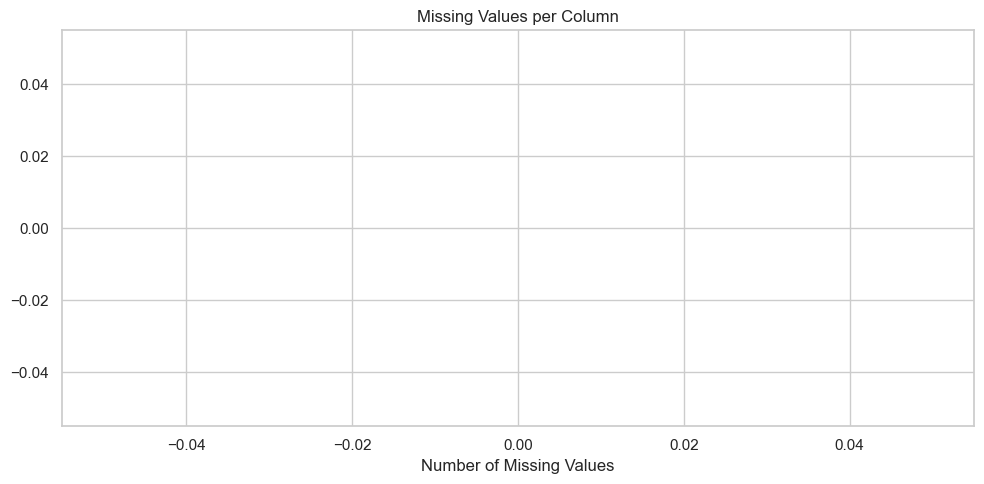

In [5]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage


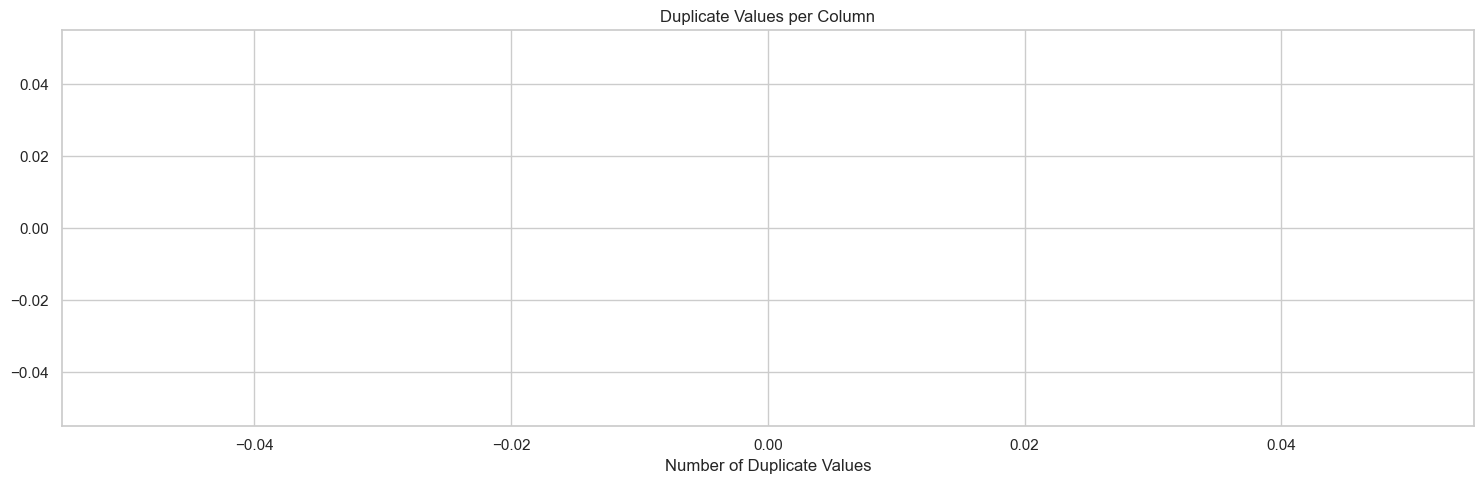

In [7]:
fig,ax = plt.subplots(figsize=(15,5))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+0.005,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Target Variabel Distribution

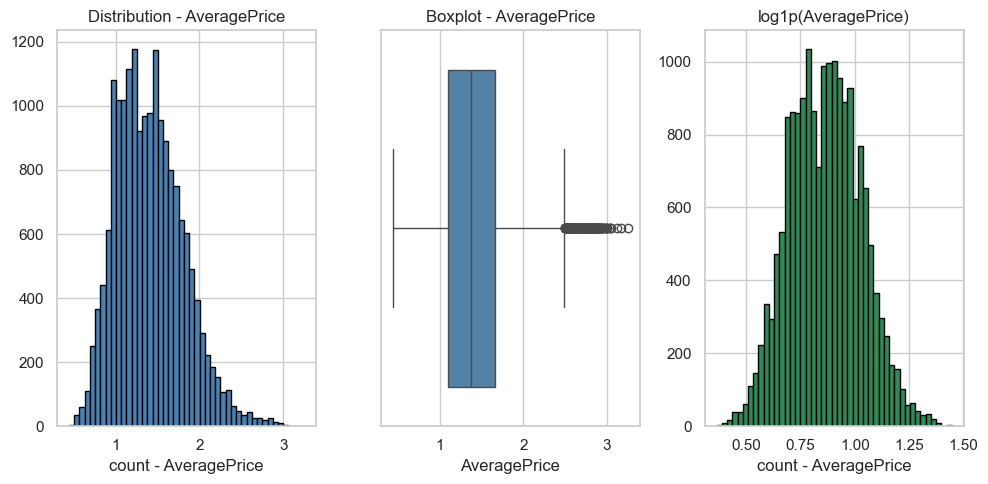

In [8]:
fig,axes = plt.subplots(1,3,figsize=(10,5))
axes[0].hist(df[y_target].dropna(),bins=45,color='steelblue',edgecolor='black')
axes[0].set_title(f'Distribution - {y_target}')
axes[0].set_xlabel(f'count - {y_target}')

sns.boxplot(x=df[y_target].dropna(),ax = axes[1],color='steelblue')
axes[1].set_title(f'Boxplot - {y_target}') 

axes[2].hist(np.log1p(df[y_target].dropna()),bins=45,color='seagreen',edgecolor='black')
axes[2].set_title(f'log1p({y_target})')
axes[2].set_xlabel(f'count - {y_target}')
plt.tight_layout()
plt.show()

In [9]:
describe = df[y_target].describe().round(3) #sudah berbentuk dataframe
y_stats = pd.DataFrame({
    y_target: [round(df[y_target].skew(), 3), round(df[y_target].kurtosis(), 3)]
},index=['Skewness', 'Kurtosis'])
df_stats = pd.concat([describe,y_stats]).T
df_stats

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
AveragePrice,18249.0,1.406,0.403,0.44,1.1,1.37,1.66,3.25,0.58,0.325


## 6. Univariat Analysis -- Numerical Features

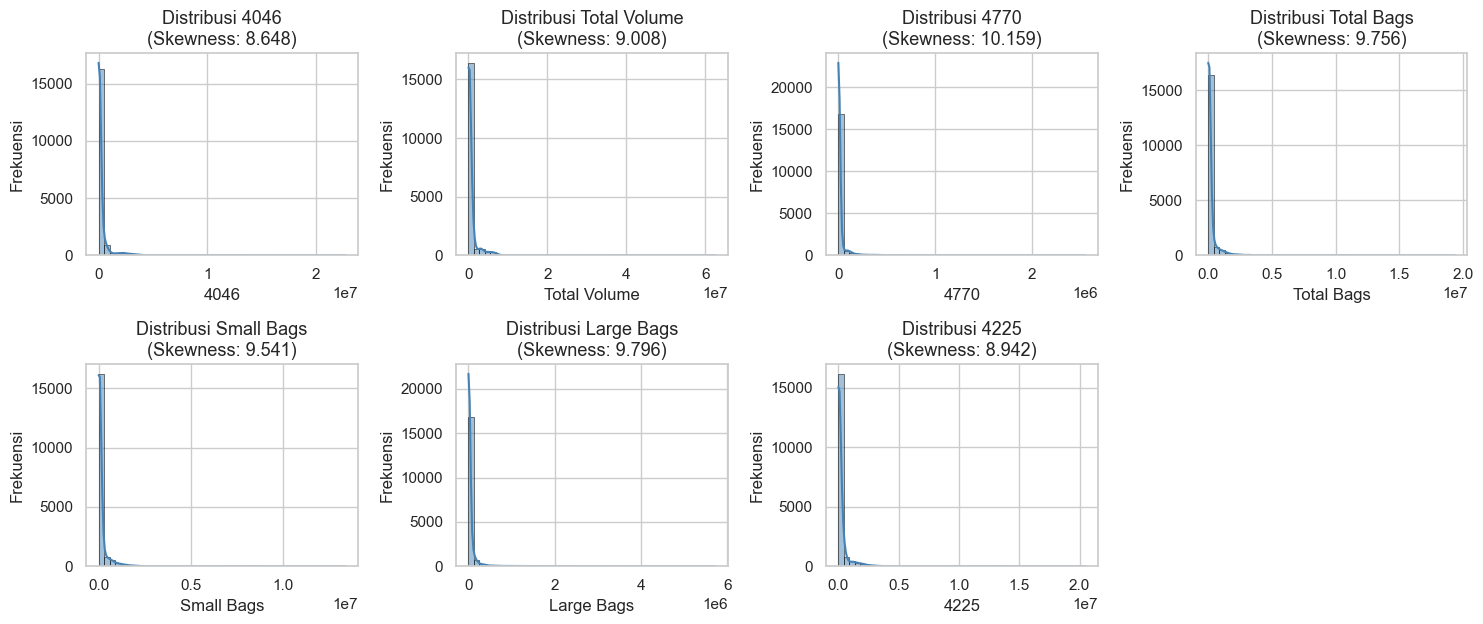

In [10]:
n_show = len(top_features)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(top_features):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 7. Univariate Analysis -- Categorical Features

In [11]:
feature_categori = df.select_dtypes(include='object').columns.to_list()
print(f'Numeric features ({len(feature_categori)}):')
print(feature_categori[:30])

Numeric features (3):
['Date', 'type', 'region']


## 8. Bivariate Analysis -- Features Numeric VS Target

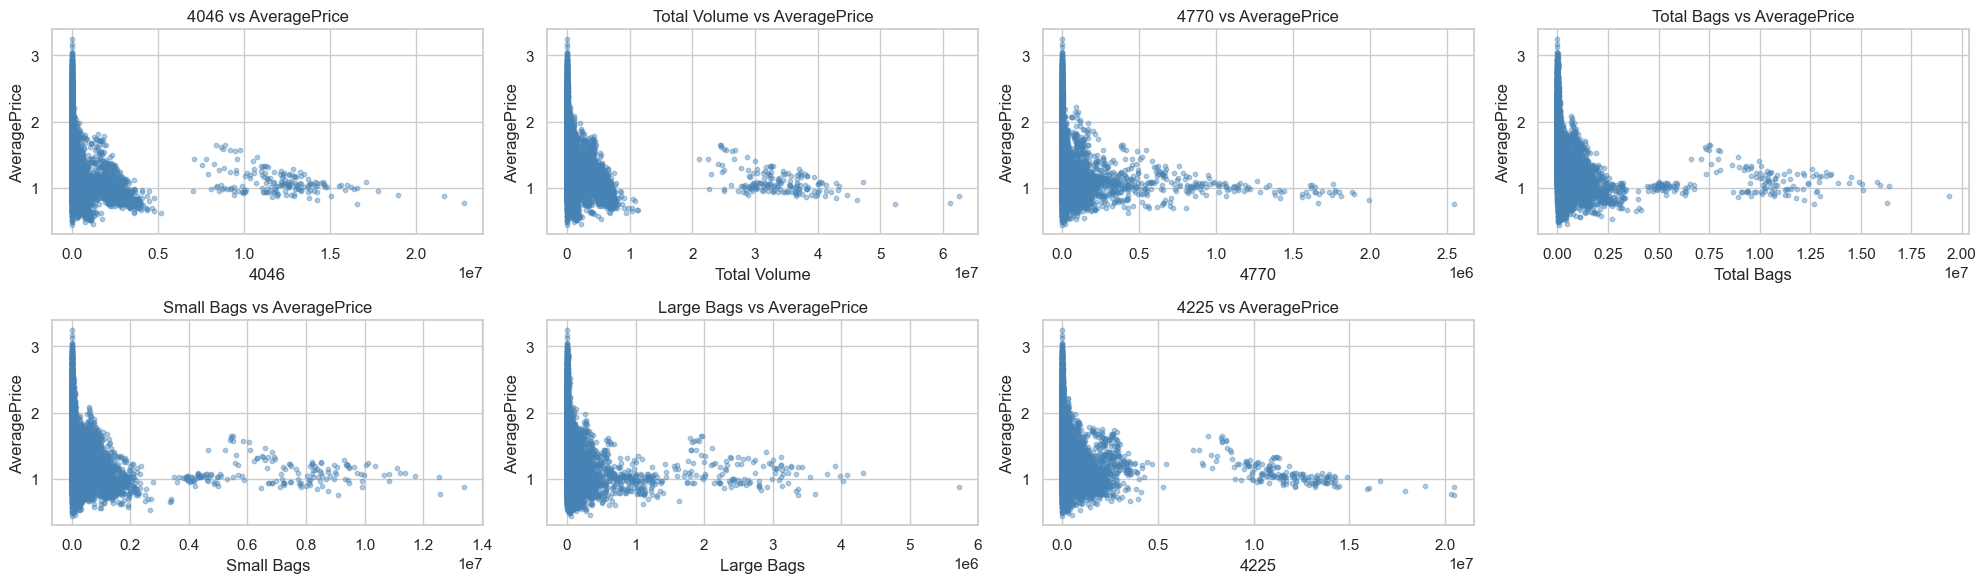

In [12]:
n_show = len(top_features)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(20,3.0*nrows))
axes = axes.flatten()
for i,feature in enumerate(top_features):
    axes[i].scatter(df[feature],df[y_target],alpha=0.4,s=10,color='steelblue')
    axes[i].set_xlabel(feature); axes[i].set_ylabel(f'{y_target}')
    axes[i].set_title(f'{feature} vs {y_target}')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

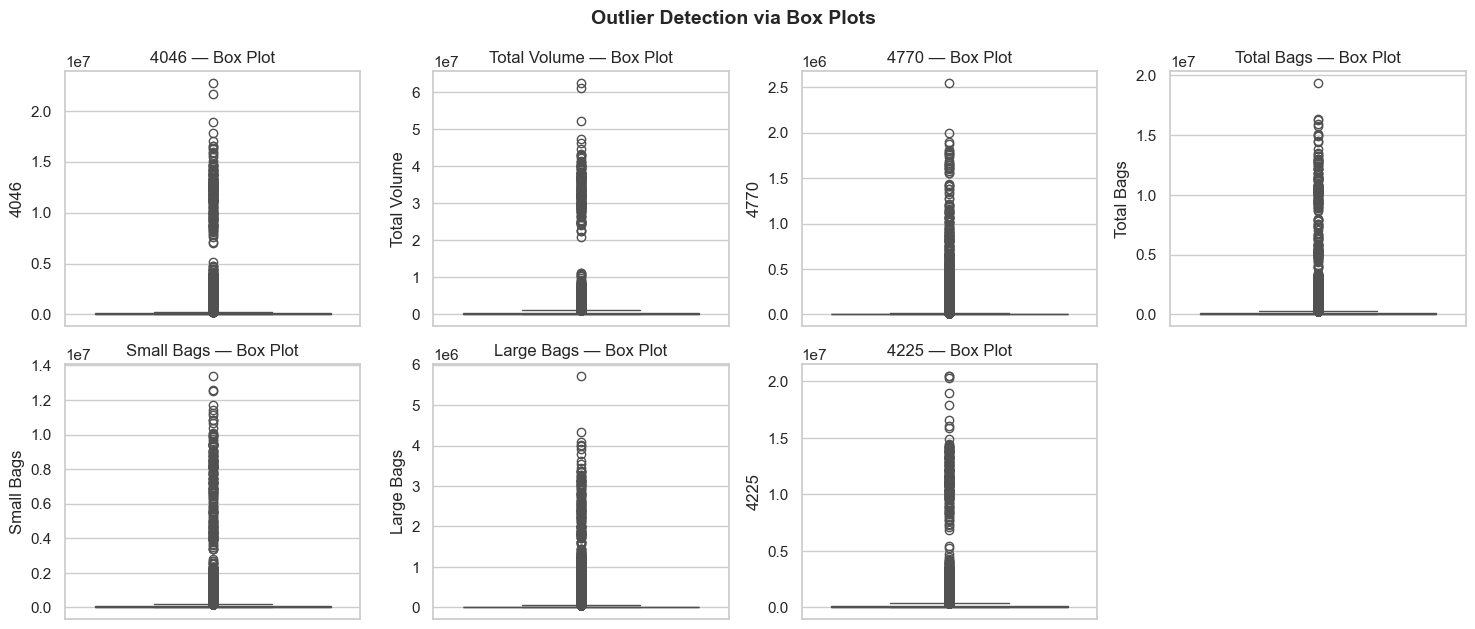

In [13]:
n_show = len(top_features)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")
for j in range(n_show, len(axes)):
        axes[j].axis('off')

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Bivariate Analysis -- Features Categoric VS Target

In [14]:
anova_results = []
for col in feature_categori:
    categories = df[col].dropna().unique()
    groups = [df[df[col] == cat][y_target].dropna() for  cat in categories]

    try:
        f_stats, p_val = stats.f_oneway(*groups)
        conclusion = "Signifikan" if p_val < 0.05 else "Tidak Signifikan"
        anova_results.append({
            'Feature': col,
            'F-Statistic': round(f_stats),
            'P-Value': round(p_val,1),
            'Conclusion': conclusion
        })
    except Exception as e:
        print(f"Gagal melakukan uji ANOVA untuk kolom {col}: {e}")
df_anova = pd.DataFrame(anova_results)
df_anova = df_anova.sort_values(by='F-Statistic',ascending=False).reset_index(drop=True)
df_anova

,Feature,F-Statistic,P-Value,Conclusion
0,type,11149,0.0,Signifikan
1,region,69,0.0,Signifikan
2,Date,18,0.0,Signifikan


## 10.Multivariat Analysis 

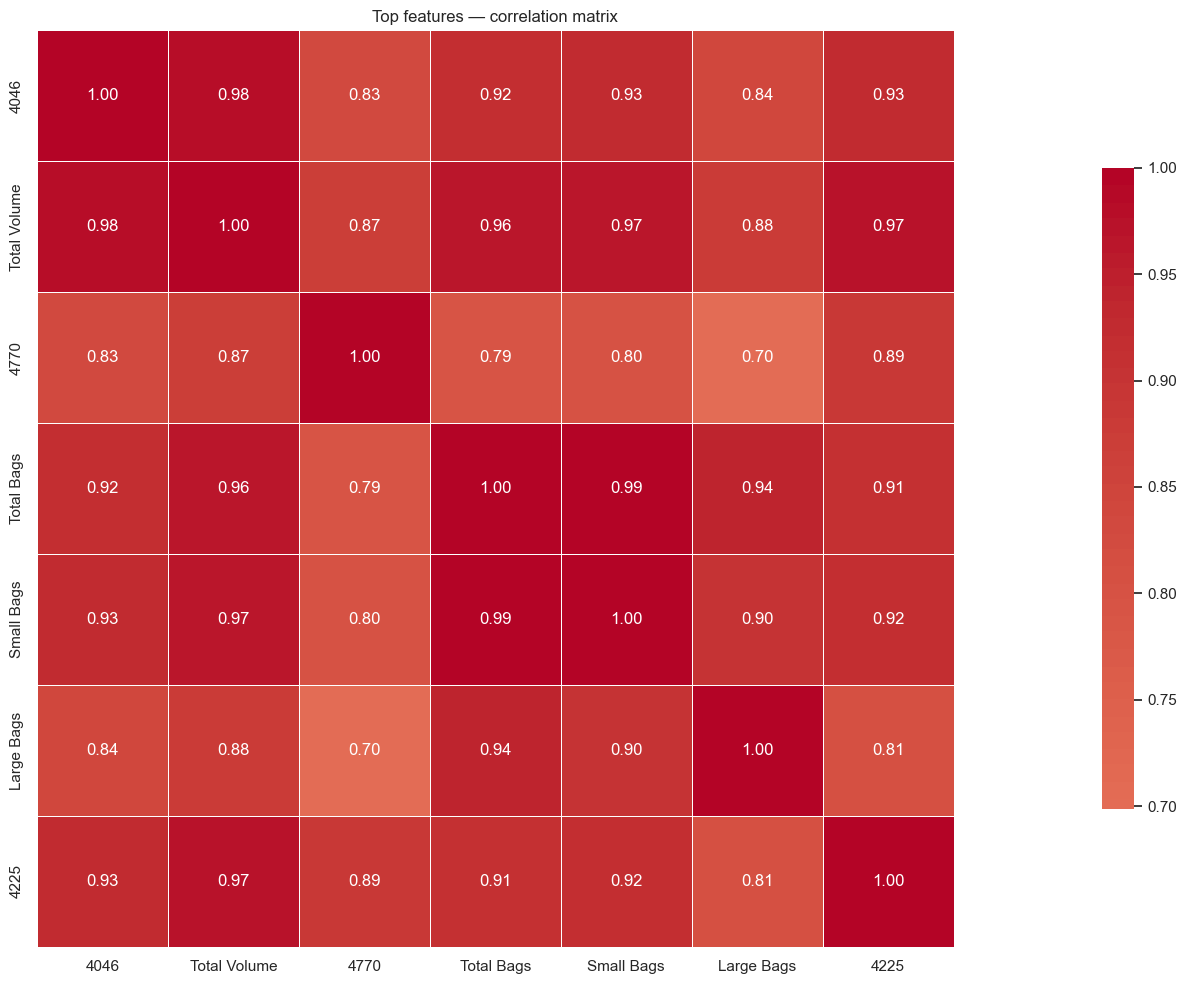

In [18]:
corr_matrix = df[top_features].corr()
plt.figure(figsize=(30,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

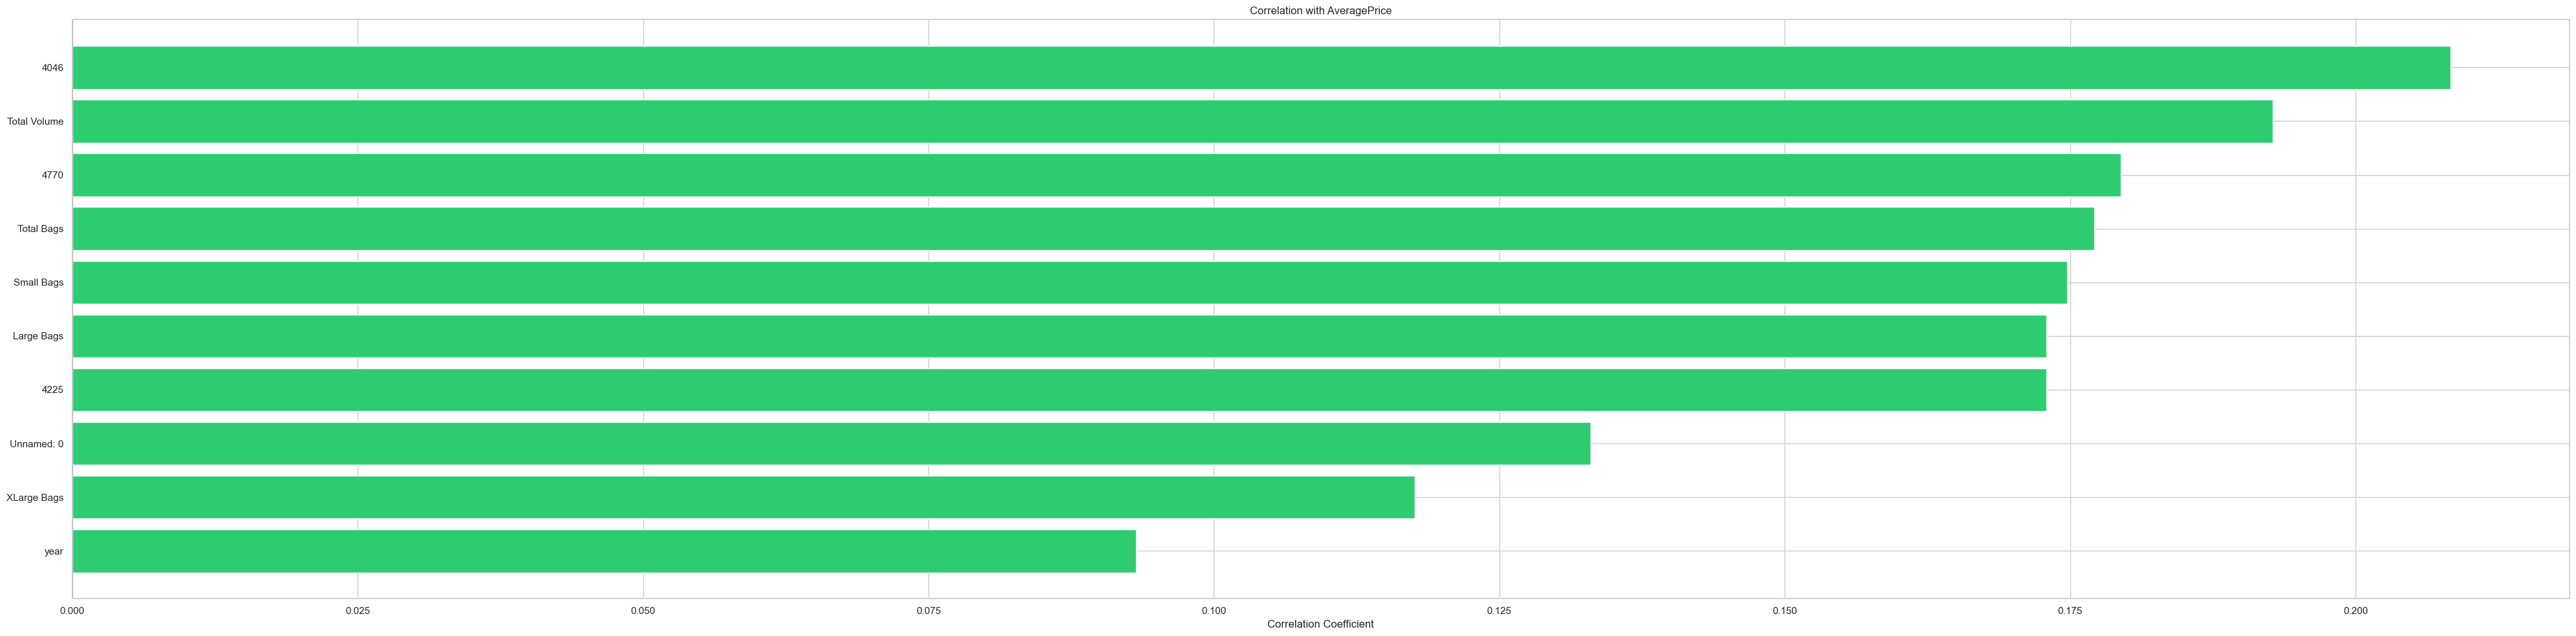

In [16]:
target_corr = df[feature_numerik].corr()[y_target].abs().drop(y_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(40, 10))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {y_target}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 11.Summary of EDA Findings

In [17]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,18249
1,Total features,13
2,Target mean,1.41
3,Target median,1.37
4,Target stddev,0.4
5,Target min,0.44
6,Target max,3.25
7,Target skewness,0.58
8,Top correlated feature,4046
9,Top correlation value,0.208
